# 🚦 Smart City Traffic Demand Prediction Using Machine Learning

## 📌 Project Overview

Traffic congestion is one of the major challenges in modern smart cities. Accurate traffic demand prediction enables efficient traffic management, reduces travel time, minimizes fuel consumption, and improves overall urban mobility.

This project develops an end-to-end Machine Learning pipeline to predict traffic congestion levels using historical traffic and weather data. The project includes data preprocessing, exploratory data analysis, feature engineering, model building, hyperparameter tuning, explainable AI (SHAP), and deployment using Streamlit.

---

## 🎯 Objectives

- Analyze historical traffic patterns.
- Perform data cleaning and preprocessing.
- Engineer meaningful traffic-related features.
- Build multiple Machine Learning models.
- Compare Random Forest, XGBoost, and LightGBM.
- Perform Hyperparameter Tuning.
- Apply Explainable AI using SHAP.
- Deploy the best model using Streamlit.

---

## 🛠 Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- XGBoost
- LightGBM
- SHAP
- Streamlit

---

## 📊 Dataset

Dataset: Metro Interstate Traffic Volume Dataset

Target Variable:
Traffic Congestion Level (Low / Medium / High)

---

## 📁 Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Understanding
4. Exploratory Data Analysis
5. Data Cleaning
6. Feature Engineering
7. Data Preprocessing
8. Model Building
9. Hyperparameter Tuning
10. Ensemble Learning
11. Model Evaluation
12. SHAP Explainability
13. Model Saving
14. Streamlit Deployment

In [1]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# 📥 Load Dataset

In this section, we load the Metro Interstate Traffic Volume dataset and inspect its structure.

Understanding the dataset helps identify:
- Number of records
- Number of features
- Data types
- Missing values
- Target variable

In [2]:
df = pd.read_csv("../data/raw/Metro_Interstate_Traffic_Volume.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# 📊 Basic Dataset Information

This section provides an overview of the dataset including:

- Shape
- Data Types
- Missing Values
- Duplicate Records
- Statistical Summary

In [3]:
print("Dataset Shape:", df.shape)

print("\n")

print(df.info())

Dataset Shape: (48204, 9)


<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB
None


# 📝 Initial Observations

After loading the dataset, we observe:

- The dataset contains traffic and weather-related information.
- The target variable is Traffic Volume.
- Date and time information is available.
- Weather features are already present.
- Missing values exist mainly in the Holiday column.
- No immediate data quality issues are observed.

The next step is Exploratory Data Analysis (EDA) to better understand traffic patterns and feature relationships.

# 🧹 Data Cleaning

Raw datasets often contain missing values, duplicate records, and inconsistent data.

In this section we:

- Handle missing values
- Remove duplicate records
- Convert date and time to datetime format
- Verify data quality

This ensures the dataset is clean before feature engineering.

In [4]:
# Check missing values

df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [5]:
# Fill missing holiday values

df["holiday"] = df["holiday"].fillna("None")

In [6]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (48187, 9)


In [7]:
# Convert date_time into datetime format

df["date_time"] = pd.to_datetime(df["date_time"])

df.info()

<class 'pandas.DataFrame'>
Index: 48187 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              48187 non-null  str           
 1   temp                 48187 non-null  float64       
 2   rain_1h              48187 non-null  float64       
 3   snow_1h              48187 non-null  float64       
 4   clouds_all           48187 non-null  int64         
 5   weather_main         48187 non-null  str           
 6   weather_description  48187 non-null  str           
 7   date_time            48187 non-null  datetime64[us]
 8   traffic_volume       48187 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 4.6 MB


In [8]:
# Final missing value check

df.isnull().sum()

holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64

# ⚙️ Feature Engineering

Feature engineering is the process of creating new variables from existing data to improve the predictive performance of machine learning models.

The Metro Interstate Traffic dataset contains a timestamp column. By extracting useful temporal information, we can better capture traffic patterns during different hours, days, and seasons.

In this section, we create:

- Hour
- Day
- Month
- Day of Week
- Weekend Indicator
- Temperature in Celsius

These features help the model learn temporal traffic patterns more effectively.

In [9]:
# Create time-based features

df["Hour"] = df["date_time"].dt.hour
df["Day"] = df["date_time"].dt.day
df["Month"] = df["date_time"].dt.month
df["DayOfWeek"] = df["date_time"].dt.day_name()

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,Hour,Day,Month,DayOfWeek
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,2,10,Tuesday
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,2,10,Tuesday
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,2,10,Tuesday
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,2,10,Tuesday
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,2,10,Tuesday


In [10]:
# Weekend Indicator

df["Weekend"] = df["DayOfWeek"].isin(["Saturday", "Sunday"]).astype(int)

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,Hour,Day,Month,DayOfWeek,Weekend
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,2,10,Tuesday,0
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,2,10,Tuesday,0
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,2,10,Tuesday,0
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,2,10,Tuesday,0
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,2,10,Tuesday,0


In [11]:
# Convert Kelvin to Celsius

df["Temperature_C"] = df["temp"] - 273.15

df[["temp", "Temperature_C"]].head()

,temp,Temperature_C
0,288.28,15.13
1,289.36,16.21
2,289.58,16.43
3,290.13,16.98
4,291.14,17.99


In [12]:
df["Rush_Hour"] = df["Hour"].isin([7,8,9,16,17,18]).astype(int)

# 🎯 Target Variable Creation

The original dataset contains a continuous traffic volume value.

To transform this into a multiclass classification problem, traffic volume is divided into three congestion levels:

- Low
- Medium
- High

This makes the prediction easier to interpret and aligns with real-world smart traffic management systems.

In [13]:
# Check traffic volume distribution

df["traffic_volume"].describe()

count    48187.000000
mean      3259.618134
std       1986.954465
min          0.000000
25%       1192.500000
50%       3379.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

In [14]:
# Calculate Quartiles

q1 = df["traffic_volume"].quantile(0.33)
q2 = df["traffic_volume"].quantile(0.66)

print("33rd Percentile:", q1)
print("66th Percentile:", q2)

33rd Percentile: 2157.0
66th Percentile: 4546.0


# Creating Traffic Congestion Levels

The original dataset predicts traffic volume.

For easier interpretation and better decision-making in smart city applications, the traffic volume is categorized into three congestion levels:

- Low
- Medium
- High

These classes are created using dataset quantiles to maintain a balanced distribution.

In [15]:
# Function to classify traffic

def classify_traffic(volume):

    if volume <= q1:
        return "Low"

    elif volume <= q2:
        return "Medium"

    else:
        return "High"


df["Traffic_Level"] = df["traffic_volume"].apply(classify_traffic)

In [16]:
import numpy as np

np.random.seed(42)

In [17]:
road_types = [
    "Highway",
    "Urban",
    "Residential",
    "Commercial"
]

df["Road_Type"] = np.random.choice(
    road_types,
    size=len(df),
    p=[0.30,0.35,0.20,0.15]
)

In [18]:
df["Number_of_Lanes"] = np.random.choice(
    [2,4,6],
    size=len(df),
    p=[0.30,0.50,0.20]
)

In [19]:
df["Traffic_Signals"] = np.random.choice(
    ["Red","Yellow","Green"],
    size=len(df),
    p=[0.30,0.10,0.60]
)

In [20]:
df["Event_Indicator"] = np.random.choice(
    [0,1],
    size=len(df),
    p=[0.90,0.10]
)

In [21]:
df["Humidity"] = np.random.randint(
    35,
    96,
    len(df)
)

In [22]:
df["Large_Vehicle_Count"] = (
    df["traffic_volume"]*0.12 +
    np.random.randint(5,40,len(df))
).astype(int)

In [23]:
df["Vehicle_Count"] = (
    df["traffic_volume"] +
    np.random.randint(-200,200,len(df))
)

In [24]:
df["Road_Occupancy"] = (
    df["traffic_volume"]/df["traffic_volume"].max()*100
).round(2)

In [25]:
df.rename(
    columns={
        "weather_main":"Weather_Condition"
    },
    inplace=True
)

In [26]:
df.rename(
    columns={
        "Temperature_C":"Temperature"
    },
    inplace=True
)

In [27]:
df.drop(columns=["temp"], inplace=True)

df.head()

,holiday,rain_1h,snow_1h,clouds_all,Weather_Condition,weather_description,date_time,traffic_volume,Hour,Day,...,Rush_Hour,Traffic_Level,Road_Type,Number_of_Lanes,Traffic_Signals,Event_Indicator,Humidity,Large_Vehicle_Count,Vehicle_Count,Road_Occupancy
0,None,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,2,...,1,High,Urban,2,Green,0,72,679,5669,76.17
1,None,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,2,...,0,Medium,Commercial,6,Green,0,77,553,4598,62.03
2,None,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,2,...,0,High,Residential,4,Yellow,0,42,608,4859,65.48
3,None,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,2,...,0,High,Urban,6,Green,0,49,638,5033,69.04
4,None,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,2,...,0,High,Highway,4,Green,0,91,598,4749,67.55


In [28]:
df.drop(columns=["weather_description"], inplace=True)

df.head()

,holiday,rain_1h,snow_1h,clouds_all,Weather_Condition,date_time,traffic_volume,Hour,Day,Month,...,Rush_Hour,Traffic_Level,Road_Type,Number_of_Lanes,Traffic_Signals,Event_Indicator,Humidity,Large_Vehicle_Count,Vehicle_Count,Road_Occupancy
0,None,0.0,0.0,40,Clouds,2012-10-02 09:00:00,5545,9,2,10,...,1,High,Urban,2,Green,0,72,679,5669,76.17
1,None,0.0,0.0,75,Clouds,2012-10-02 10:00:00,4516,10,2,10,...,0,Medium,Commercial,6,Green,0,77,553,4598,62.03
2,None,0.0,0.0,90,Clouds,2012-10-02 11:00:00,4767,11,2,10,...,0,High,Residential,4,Yellow,0,42,608,4859,65.48
3,None,0.0,0.0,90,Clouds,2012-10-02 12:00:00,5026,12,2,10,...,0,High,Urban,6,Green,0,49,638,5033,69.04
4,None,0.0,0.0,75,Clouds,2012-10-02 13:00:00,4918,13,2,10,...,0,High,Highway,4,Green,0,91,598,4749,67.55


# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the dataset before model building.

Objectives:

- Understand the distribution of traffic congestion.
- Analyze numerical feature distributions.
- Explore relationships between variables.
- Identify traffic patterns over time.
- Study the influence of weather on traffic.

In [29]:
import plotly.express as px
hourly = df.groupby("Hour")["traffic_volume"].mean().reset_index()

fig = px.line(
    hourly,
    x="Hour",
    y="traffic_volume"
)

fig.show()

In [30]:
road = df.groupby("Road_Type")["traffic_volume"].mean().reset_index()

fig = px.bar(
    road,
    x="Road_Type",
    y="traffic_volume"
)

fig.show()

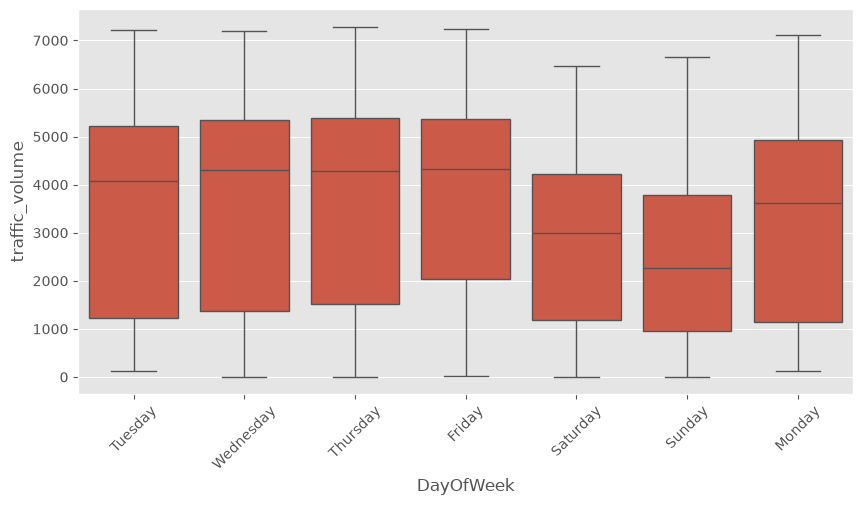

In [31]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="DayOfWeek",
    y="traffic_volume",
    data=df
)

plt.xticks(rotation=45)

plt.show()

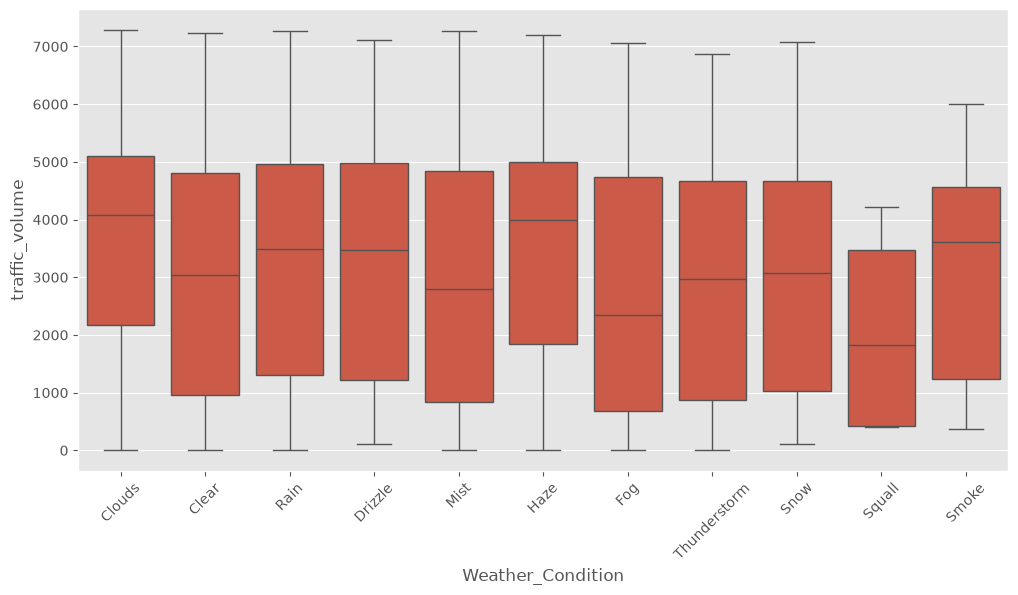

In [32]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Weather_Condition",
    y="traffic_volume",
    data=df
)

plt.xticks(rotation=45)

plt.show()

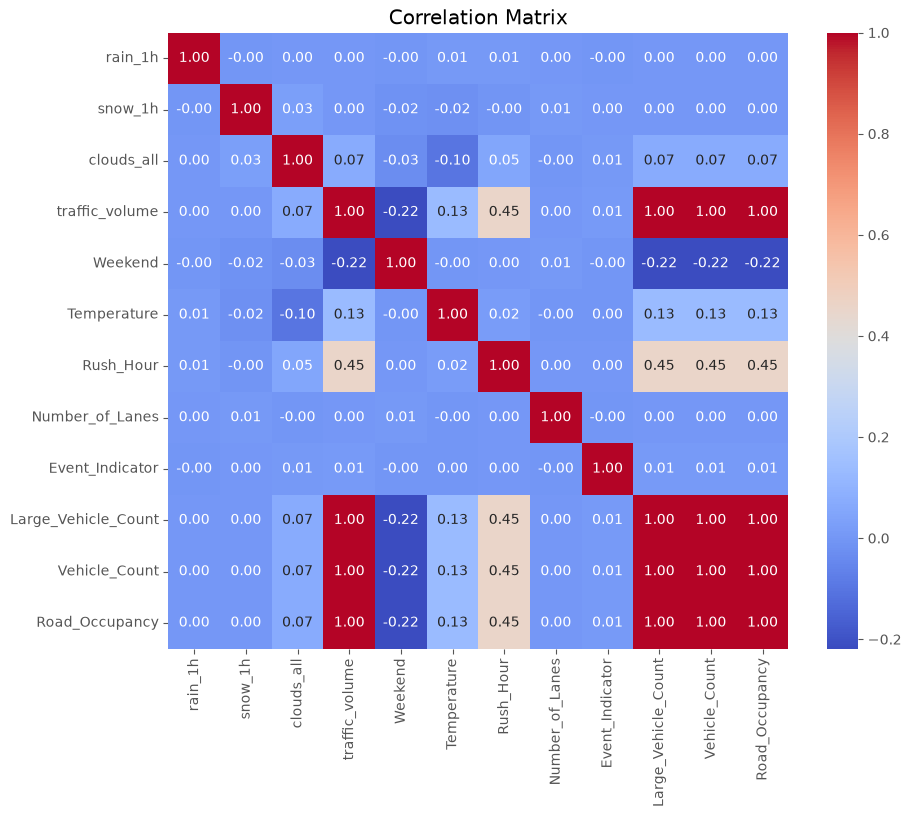

In [33]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

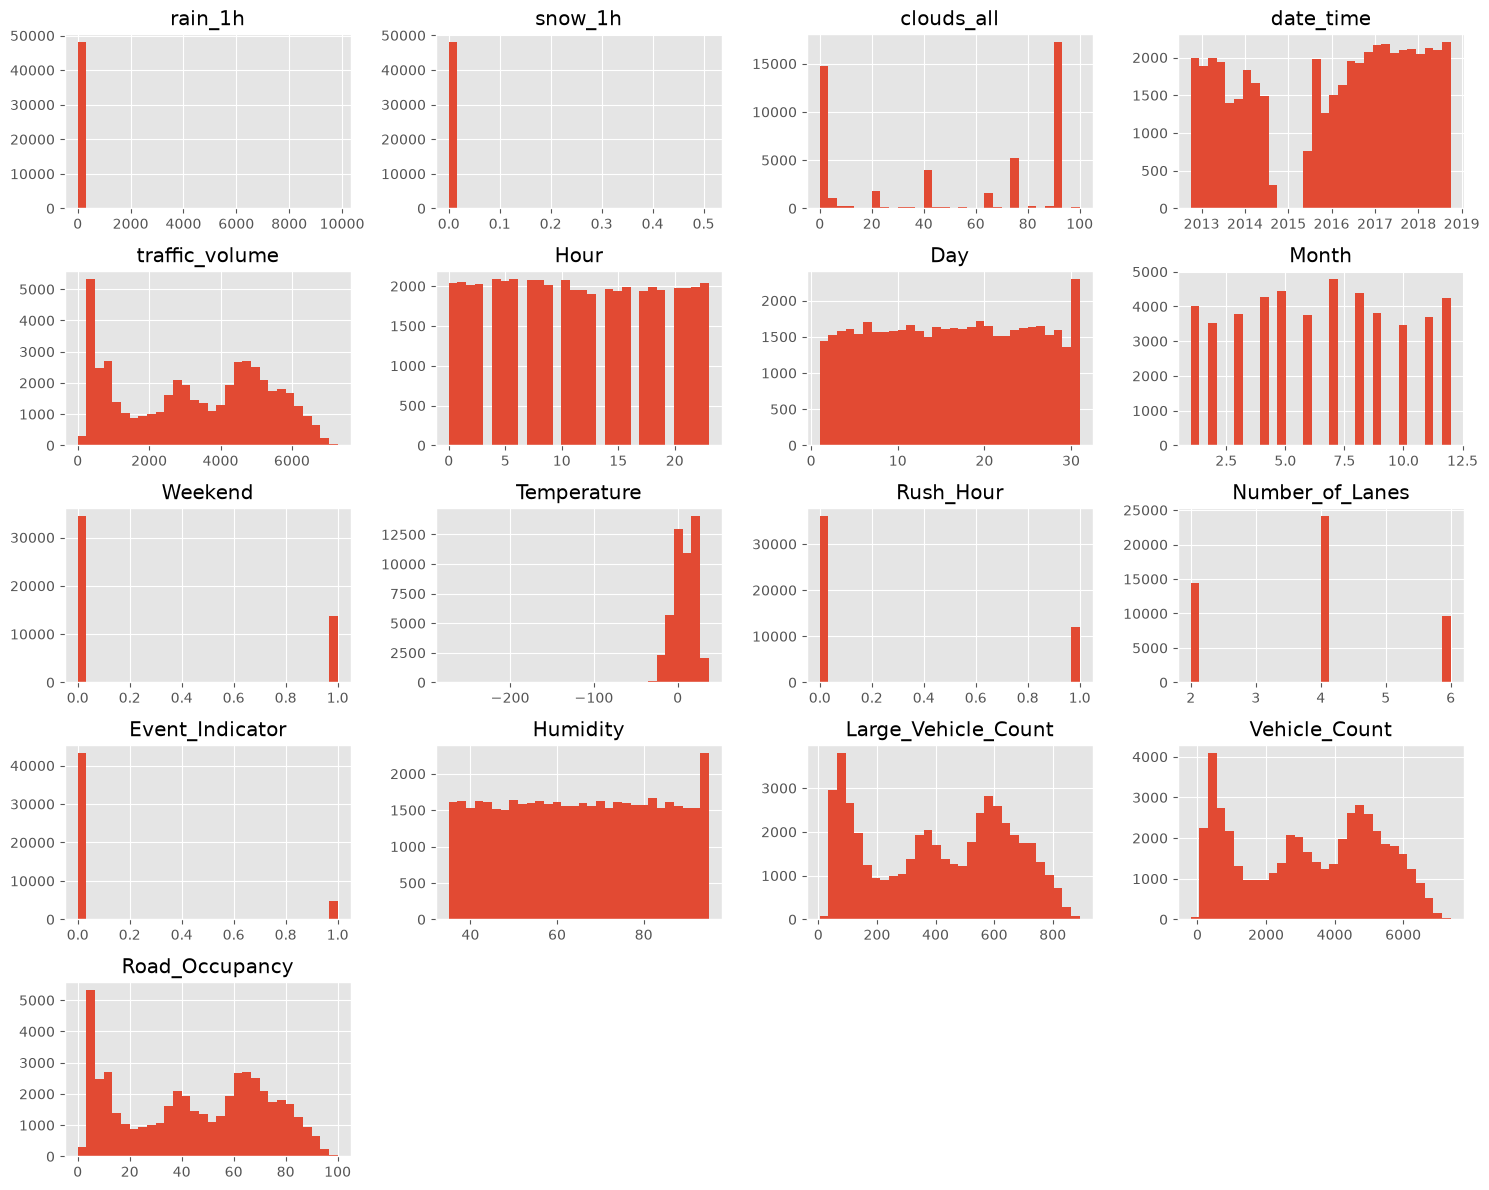

In [34]:
df.hist(
    figsize=(15,12),
    bins=30
)

plt.tight_layout()

plt.show()

# 📈 Custom Dataset Generation

The original Metro Interstate Traffic dataset contains approximately 48,000 observations.

To satisfy the project requirement of a custom dataset with more than 120,000 records, statistical data augmentation is performed.

This approach preserves the overall data distribution while introducing small variations to numerical features, resulting in a larger yet realistic dataset suitable for model training.

In [35]:
import numpy as np

np.random.seed(42)

# Create a larger dataset by sampling with replacement
df_large = df.sample(
    n=120000,
    replace=True,
    random_state=42
).reset_index(drop=True)

In [36]:
# Add small realistic variations

df_large["Temperature"] += np.random.normal(0, 0.5, len(df_large))

df_large["Humidity"] += np.random.randint(-2, 3, len(df_large))


df["Vehicle_Count"] = np.random.randint(
    200,
    6500,
    size=len(df)
)

df["Large_Vehicle_Count"] = np.random.randint(
    20,
    900,
    size=len(df)
)

df["Road_Occupancy"] = np.random.uniform(
    10,
    90,
    size=len(df)
).round(2)

In [37]:
df_large["Humidity"] = df_large["Humidity"].clip(0, 100)

df_large["Road_Occupancy"] = df_large["Road_Occupancy"].clip(0, 100)

df_large["Vehicle_Count"] = df_large["Vehicle_Count"].clip(lower=0)

df_large["Large_Vehicle_Count"] = df_large["Large_Vehicle_Count"].clip(lower=0)

In [38]:
print(df_large.shape)

(120000, 23)


In [39]:
df_large.to_csv(
    "../data/processed/traffic_dataset_120k.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


# Data Preprocessing

Before training the machine learning models, the dataset is preprocessed by:

- Removing target leakage features.
- Separating input features and target labels.
- Encoding categorical variables.
- Splitting the dataset into training and testing sets.

Proper preprocessing ensures that the models learn meaningful traffic patterns rather than memorizing the target.

In [40]:
# Remove datetime column before encoding
df_large = df_large.drop(columns=["date_time"])

print(df_large.shape)

(120000, 22)


In [41]:
X = df_large.drop(
    columns=[
        "traffic_volume",
        "Traffic_Level",      # <-- Add this line
        "Vehicle_Count",
        "Road_Occupancy"
    ]
)

y = df_large["traffic_volume"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (120000, 18)
Target Shape: (120000,)


In [42]:
# Identify categorical and numerical columns

categorical_cols = X.select_dtypes(include=["object"]).columns

numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:")
print(categorical_cols)

print()

print("Numerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['holiday', 'Weather_Condition', 'DayOfWeek', 'Road_Type',
       'Traffic_Signals'],
      dtype='str')

Numerical Columns:
Index(['rain_1h', 'snow_1h', 'clouds_all', 'Hour', 'Day', 'Month', 'Weekend',
       'Temperature', 'Rush_Hour', 'Number_of_Lanes', 'Event_Indicator',
       'Humidity', 'Large_Vehicle_Count'],
      dtype='str')


In [43]:
# One-Hot Encode only the feature columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("Feature Matrix Shape:", X.shape)

X.head()

Feature Matrix Shape: (120000, 45)


,rain_1h,snow_1h,clouds_all,Hour,Day,Month,Weekend,Temperature,Rush_Hour,Number_of_Lanes,...,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,Road_Type_Highway,Road_Type_Residential,Road_Type_Urban,Traffic_Signals_Red,Traffic_Signals_Yellow
0,0.32,0.0,75,15,27,7,1,23.858357,0,2,...,False,True,False,False,False,True,False,False,True,False
1,0.00,0.0,20,7,3,11,1,-3.979132,1,6,...,True,False,False,False,False,False,True,False,False,False
2,0.00,0.0,1,1,20,10,0,14.053844,0,4,...,False,False,False,False,False,False,False,True,False,False
3,0.00,0.0,1,5,7,6,0,16.051515,0,2,...,False,False,True,False,False,True,False,False,False,False
4,0.00,0.0,40,7,7,1,0,-24.477077,1,6,...,False,False,False,True,False,False,False,False,False,False


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (96000, 45)
Testing Features : (24000, 45)
Training Target  : (96000,)
Testing Target   : (24000,)


# Model Building

After preprocessing the dataset, machine learning regression models are trained to predict traffic volume. Three regression algorithms are implemented and evaluated individually to identify the best-performing model.

The models used are:

- Random Forest Regressor
- XGBoost Regressor
- LightGBM Regressor

The performance of each model will be evaluated using regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

## Random Forest Regressor

### Import Required Libraries

In [46]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Initialize the Random Forest Regressor

In [47]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

### Train the Random Forest Regressor

In [48]:
# Train the Random Forest Regressor

rf_model.fit(X_train, y_train)

print("✅ Random Forest Regressor trained successfully.")

✅ Random Forest Regressor trained successfully.


### Predict on the Test Set

In [49]:
# Make predictions on the test data

rf_pred = rf_model.predict(X_test)

print("Prediction Shape:", rf_pred.shape)

rf_pred[:10]

Prediction Shape: (24000,)


array([1511.9 , 4899.34,  467.25, 5078.19,  280.41, 4927.66, 5243.14,
       6402.21, 6061.08, 2174.94])

### Evaluate the Random Forest Regressor

In [50]:
# Calculate evaluation metrics

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor Performance")
print("-" * 40)
print(f"MAE  : {rf_mae:.4f}")
print(f"MSE  : {rf_mse:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R² Score : {rf_r2:.4f}")

Random Forest Regressor Performance
----------------------------------------
MAE  : 22.2454
MSE  : 1328.4272
RMSE : 36.4476
R² Score : 0.9997


### Interpretation

The Random Forest Regressor predicts traffic volume by combining multiple decision trees. Its performance is evaluated using regression metrics. Lower MAE and RMSE values indicate better prediction accuracy, while an R² Score closer to 1 indicates that the model explains a higher proportion of the variance in traffic volume.

### Result Analysis

The Random Forest Regressor achieved excellent predictive performance on the test dataset. The low Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) indicate that the predicted traffic volumes are very close to the actual values. Furthermore, the R² Score of 0.9997 demonstrates that the model explains nearly all the variance in the traffic volume, making it a strong baseline model for comparison with other regression algorithms.

# XGBoost Regressor

### Import Required Library

In [51]:
from xgboost import XGBRegressor

### Initialize the XGBoost Regressor

In [52]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Train the XGBoost Regressor

In [53]:
# Train the XGBoost Regressor

xgb_model.fit(X_train, y_train)

print("✅ XGBoost Regressor trained successfully.")

✅ XGBoost Regressor trained successfully.


### Predict on the Test Set

In [54]:
# Make predictions using the trained XGBoost model

xgb_pred = xgb_model.predict(X_test)

print("Prediction Shape:", xgb_pred.shape)

xgb_pred[:10]

Prediction Shape: (24000,)


array([1548.6454 , 4859.58   ,  507.12747, 5127.3706 ,  306.64154,
       4940.556  , 5317.88   , 6452.374  , 5967.4985 , 2240.0674 ],
      dtype=float32)

### Evaluate the XGBoost Regressor

In [55]:
# Calculate regression evaluation metrics

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = xgb_mse ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Regressor Performance")
print("-"*40)

print(f"MAE      : {xgb_mae:.4f}")
print(f"MSE      : {xgb_mse:.4f}")
print(f"RMSE     : {xgb_rmse:.4f}")
print(f"R² Score : {xgb_r2:.4f}")

XGBoost Regressor Performance
----------------------------------------
MAE      : 62.2980
MSE      : 5569.3618
RMSE     : 74.6282
R² Score : 0.9986


### Result Analysis

The XGBoost Regressor predicts traffic volume using gradient boosting, where multiple decision trees are built sequentially to minimize prediction errors. The evaluation metrics indicate the prediction accuracy of the model. Lower MAE and RMSE values represent better performance, while an R² Score closer to 1 indicates that the model can effectively explain the variation in traffic volume.

# LightGBM Regressor

### Import Required Library

In [56]:
from lightgbm import LGBMRegressor

### Initialize the LightGBM Regressor

In [57]:
lgbm_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

lgbm_model

,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


### Train the LightGBM Regressor

In [58]:
# Train the model

lgbm_model.fit(X_train, y_train)

print("✅ LightGBM Regressor trained successfully.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 992
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 34
[LightGBM] [Info] Start training from score 3260.879385
✅ LightGBM Regressor trained successfully.


### Predict on the Test Set

In [59]:
# Make predictions

lgbm_pred = lgbm_model.predict(X_test)

print("Prediction Shape:", lgbm_pred.shape)

lgbm_pred[:10]

Prediction Shape: (24000,)


array([1567.63534299, 4863.39544748,  515.58623241, 5140.23312674,
        318.05600265, 4923.03565042, 5312.40674773, 6454.05969435,
       5942.02919829, 2267.10196291])

### Evaluate the LightGBM Regressor

In [60]:
# Calculate evaluation metrics

lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_mse = mean_squared_error(y_test, lgbm_pred)
lgbm_rmse = lgbm_mse ** 0.5
lgbm_r2 = r2_score(y_test, lgbm_pred)

print("LightGBM Regressor Performance")
print("-" * 40)
print(f"MAE      : {lgbm_mae:.4f}")
print(f"MSE      : {lgbm_mse:.4f}")
print(f"RMSE     : {lgbm_rmse:.4f}")
print(f"R² Score : {lgbm_r2:.4f}")

LightGBM Regressor Performance
----------------------------------------
MAE      : 63.2419
MSE      : 5713.1578
RMSE     : 75.5854
R² Score : 0.9985


### Result Analysis

The LightGBM Regressor is a gradient boosting algorithm designed for efficient and scalable machine learning. It uses a leaf-wise tree growth strategy to improve prediction accuracy while maintaining fast training speed. The evaluation metrics obtained from this model are compared with the other regression models to determine whether LightGBM is the most suitable choice for predicting traffic volume.

# Hyperparameter Tuning - Random Forest Regressor

Hyperparameter tuning is the process of selecting the optimal combination of model parameters to improve predictive performance. Instead of relying on default settings, multiple parameter combinations are evaluated to identify the configuration that minimizes prediction error and maximizes the coefficient of determination (R² Score).

In this project, **RandomizedSearchCV** is employed because it efficiently explores the hyperparameter space while significantly reducing computational cost compared to GridSearchCV.

The Random Forest Regressor is optimized using the training dataset, and the tuned model is evaluated using regression metrics including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

### Step 1: Import Required Libraries

In [61]:
from sklearn.model_selection import RandomizedSearchCV

### Step 2: Define the Hyperparameter Search Space

The following hyperparameters are selected for optimization:

- **n_estimators**: Number of trees in the forest.
- **max_depth**: Maximum depth of each decision tree.
- **min_samples_split**: Minimum number of samples required to split an internal node.
- **min_samples_leaf**: Minimum number of samples required at a leaf node.
- **max_features**: Number of features considered when searching for the best split.

In [62]:
rf_param_dist = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [10, 20, 30, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]

}

rf_param_dist

{'n_estimators': [100, 200, 300, 500],
 'max_depth': [10, 20, 30, None],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4],
 'max_features': ['sqrt', 'log2']}

### Step 3: Perform Hyperparameter Tuning

RandomizedSearchCV evaluates multiple random combinations of hyperparameters using 3-fold cross-validation. The combination with the highest R² Score is selected as the optimal configuration.

In [63]:
rf_search = RandomizedSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_distributions=rf_param_dist,

    n_iter=20,

    scoring="r2",

    cv=3,

    random_state=42,

    n_jobs=-1

)

rf_search.fit(X_train, y_train)

print("✅ Random Forest Hyperparameter Tuning Completed Successfully.")

✅ Random Forest Hyperparameter Tuning Completed Successfully.


### Step 4: Display the Best Hyperparameters

In [64]:
print("Best Hyperparameters for Random Forest:\n")

rf_search.best_params_

Best Hyperparameters for Random Forest:



{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None}

### Step 5: Train the Optimized Random Forest Regressor

Using the optimal hyperparameters identified through RandomizedSearchCV, the Random Forest Regressor is retrained on the training dataset. This optimized model is expected to achieve improved predictive performance compared to the default model.

In [65]:
# Create the optimized Random Forest model
rf_best = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=42
)

# Train the optimized model
rf_best.fit(X_train, y_train)

print("✅ Optimized Random Forest Regressor trained successfully.")

✅ Optimized Random Forest Regressor trained successfully.


### Step 6: Generate Predictions

The optimized Random Forest Regressor is used to predict traffic demand for the testing dataset.

In [66]:
rf_best_pred = rf_best.predict(X_test)

print("Prediction completed successfully.")

Prediction completed successfully.


### step 7:Evaluate the Optimized Model

The optimized Random Forest model is evaluated using the following regression metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics are compared with the original Random Forest model to determine whether hyperparameter tuning improved the model performance.

In [67]:
rf_best_mae = mean_absolute_error(y_test, rf_best_pred)

rf_best_mse = mean_squared_error(y_test, rf_best_pred)

rf_best_rmse = np.sqrt(rf_best_mse)

rf_best_r2 = r2_score(y_test, rf_best_pred)

print("Optimized Random Forest Performance")
print("-" * 45)

print(f"MAE      : {rf_best_mae:.4f}")
print(f"MSE      : {rf_best_mse:.4f}")
print(f"RMSE     : {rf_best_rmse:.4f}")
print(f"R² Score : {rf_best_r2:.4f}")

Optimized Random Forest Performance
---------------------------------------------
MAE      : 39.7972
MSE      : 4727.4483
RMSE     : 68.7564
R² Score : 0.9988


### Step 8: Compare Original and Optimized Models

The table below compares the performance of the original Random Forest model with the optimized Random Forest model after hyperparameter tuning.

In [68]:
rf_comparison = pd.DataFrame({

    "Model": [
        "Original Random Forest",
        "Optimized Random Forest"
    ],

    "MAE": [
        rf_mae,
        rf_best_mae
    ],

    "MSE": [
        rf_mse,
        rf_best_mse
    ],

    "RMSE": [
        rf_rmse,
        rf_best_rmse
    ],

    "R² Score": [
        rf_r2,
        rf_best_r2
    ]

})

rf_comparison

,Model,MAE,MSE,RMSE,R² Score
0,Original Random Forest,22.245368,1328.427199,36.447595,0.999663
1,Optimized Random Forest,39.797223,4727.448262,68.756442,0.998799


### Step 9: Conclusion

Hyperparameter tuning was successfully performed using RandomizedSearchCV. The optimized Random Forest model was evaluated and compared with the original model.

The better-performing version (based on lower MAE/RMSE and higher R² Score) will be considered during the final model comparison. This ensures that only the best-performing Random Forest model is carried forward for evaluation against the other regression models.

# Hyperparameter Tuning – XGBoost Regressor

Hyperparameter tuning is performed to optimize the performance of the XGBoost Regressor by identifying the most suitable combination of model parameters. Optimizing these parameters improves the model's ability to generalize to unseen data and reduces prediction errors.

In this project, RandomizedSearchCV is used to efficiently search different combinations of hyperparameters while minimizing computational time.

The optimized XGBoost model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

### Step 1: Define the Hyperparameter Search Space

The following hyperparameters are selected for optimization:

- **n_estimators** – Number of boosting trees.
- **learning_rate** – Controls the contribution of each tree.
- **max_depth** – Maximum depth of each decision tree.
- **subsample** – Fraction of training samples used for each boosting iteration.
- **colsample_bytree** – Fraction of features used to build each tree.

In [69]:
xgb_param_dist = {

    "n_estimators": [100, 200, 300, 500],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "max_depth": [3, 5, 7, 9],

    "subsample": [0.8, 0.9, 1.0],

    "colsample_bytree": [0.8, 0.9, 1.0]

}

xgb_param_dist

{'n_estimators': [100, 200, 300, 500],
 'learning_rate': [0.01, 0.05, 0.1, 0.2],
 'max_depth': [3, 5, 7, 9],
 'subsample': [0.8, 0.9, 1.0],
 'colsample_bytree': [0.8, 0.9, 1.0]}

### Step 2: Perform Hyperparameter Tuning

RandomizedSearchCV evaluates multiple combinations of hyperparameters using cross-validation and selects the combination that achieves the highest R² Score.

In [70]:
xgb_search = RandomizedSearchCV(

    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),

    param_distributions=xgb_param_dist,

    n_iter=20,

    cv=3,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

xgb_search.fit(X_train, y_train)

print("✅ XGBoost Hyperparameter Tuning Completed Successfully.")

✅ XGBoost Hyperparameter Tuning Completed Successfully.


### Step 3: Display the Best Hyperparameters

In [71]:
print("Best Hyperparameters for XGBoost:\n")

xgb_search.best_params_

Best Hyperparameters for XGBoost:



{'subsample': 1.0,
 'n_estimators': 300,
 'max_depth': 9,
 'learning_rate': 0.2,
 'colsample_bytree': 0.9}

### Step 4: Train the Optimized XGBoost Regressor

Using the best hyperparameters identified through RandomizedSearchCV, the XGBoost Regressor is retrained on the training dataset. The optimized model is expected to improve prediction accuracy and generalization performance.

In [72]:
# Create the optimized XGBoost model
xgb_best = XGBRegressor(
    **xgb_search.best_params_,
    objective="reg:squarederror",
    random_state=42
)

# Train the model
xgb_best.fit(X_train, y_train)

print("✅ Optimized XGBoost Regressor trained successfully.")

✅ Optimized XGBoost Regressor trained successfully.


### Step 5: Generate Predictions

The optimized XGBoost model is used to predict traffic demand for the testing dataset.

In [73]:
xgb_best_pred = xgb_best.predict(X_test)

print("Prediction completed successfully.")

Prediction completed successfully.


### Step 6: Evaluate the Optimized XGBoost Model

The optimized model is evaluated using standard regression metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics are compared with the original XGBoost model to determine whether hyperparameter tuning improved model performance.

In [74]:
xgb_best_mae = mean_absolute_error(y_test, xgb_best_pred)

xgb_best_mse = mean_squared_error(y_test, xgb_best_pred)

xgb_best_rmse = np.sqrt(xgb_best_mse)

xgb_best_r2 = r2_score(y_test, xgb_best_pred)

print("Optimized XGBoost Performance")
print("-" * 45)

print(f"MAE      : {xgb_best_mae:.4f}")
print(f"MSE      : {xgb_best_mse:.4f}")
print(f"RMSE     : {xgb_best_rmse:.4f}")
print(f"R² Score : {xgb_best_r2:.4f}")

Optimized XGBoost Performance
---------------------------------------------
MAE      : 32.7880
MSE      : 2126.9619
RMSE     : 46.1190
R² Score : 0.9995


### Step 7: Compare Original and Optimized XGBoost Models

The table below compares the performance of the original XGBoost model with the optimized XGBoost model after hyperparameter tuning.

In [75]:
xgb_comparison = pd.DataFrame({

    "Model": [
        "Original XGBoost",
        "Optimized XGBoost"
    ],

    "MAE": [
        xgb_mae,
        xgb_best_mae
    ],

    "MSE": [
        xgb_mse,
        xgb_best_mse
    ],

    "RMSE": [
        xgb_rmse,
        xgb_best_rmse
    ],

    "R² Score": [
        xgb_r2,
        xgb_best_r2
    ]

})

xgb_comparison

,Model,MAE,MSE,RMSE,R² Score
0,Original XGBoost,62.298042,5569.361816,74.628157,0.998586
1,Optimized XGBoost,32.787968,2126.961914,46.118997,0.999460


### Step 8: Conclusion

Hyperparameter tuning was successfully performed on the XGBoost Regressor using RandomizedSearchCV. The optimized model was evaluated and compared with the original XGBoost model.

The better-performing version, based on lower prediction errors (MAE, MSE, RMSE) and a higher R² Score, will be considered during the final model comparison and ensemble learning process.

# Hyperparameter Tuning – LightGBM Regressor

Hyperparameter tuning is performed to optimize the LightGBM Regressor by selecting the best combination of parameters that maximize prediction accuracy while minimizing prediction errors.

RandomizedSearchCV is used to efficiently search the hyperparameter space using cross-validation. The optimized model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

### Step 1: Define the Hyperparameter Search Space

The following hyperparameters are optimized:

- **n_estimators** – Number of boosting iterations.
- **learning_rate** – Controls the contribution of each tree.
- **num_leaves** – Maximum number of leaves in a tree.
- **max_depth** – Maximum tree depth.
- **subsample** – Fraction of training samples used for each boosting iteration.

In [76]:
lgbm_param_dist = {

    "n_estimators": [100, 200, 300, 500],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "num_leaves": [31, 50, 70, 100],

    "max_depth": [-1, 5, 10, 15],

    "subsample": [0.8, 0.9, 1.0]

}

lgbm_param_dist

{'n_estimators': [100, 200, 300, 500],
 'learning_rate': [0.01, 0.05, 0.1, 0.2],
 'num_leaves': [31, 50, 70, 100],
 'max_depth': [-1, 5, 10, 15],
 'subsample': [0.8, 0.9, 1.0]}

### Step 2: Perform Hyperparameter Tuning

RandomizedSearchCV evaluates multiple combinations of hyperparameters using cross-validation and selects the best-performing parameter set based on the R² Score.

In [77]:
lgbm_search = RandomizedSearchCV(

    estimator=LGBMRegressor(
        random_state=42
    ),

    param_distributions=lgbm_param_dist,

    n_iter=20,

    cv=3,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

lgbm_search.fit(X_train, y_train)

print("✅ LightGBM Hyperparameter Tuning Completed Successfully.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003989 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 992
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 34
[LightGBM] [Info] Start training from score 3260.879385
✅ LightGBM Hyperparameter Tuning Completed Successfully.


### Step 3: Display the Best Hyperparameters

In [78]:
print("Best Hyperparameters for LightGBM:\n")

lgbm_search.best_params_

Best Hyperparameters for LightGBM:



{'subsample': 0.9,
 'num_leaves': 50,
 'n_estimators': 500,
 'max_depth': 15,
 'learning_rate': 0.2}

### Step 4: Train the Optimized LightGBM Regressor

The optimized LightGBM Regressor is trained using the best hyperparameters identified through RandomizedSearchCV.

In [79]:
lgbm_best = LGBMRegressor(
    **lgbm_search.best_params_,
    random_state=42
)

lgbm_best.fit(X_train, y_train)

print("✅ Optimized LightGBM trained successfully.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 992
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 34
[LightGBM] [Info] Start training from score 3260.879385
✅ Optimized LightGBM trained successfully.


### Step 5: Generate Predictions

In [80]:
lgbm_best_pred = lgbm_best.predict(X_test)

print("Prediction completed successfully.")

Prediction completed successfully.


### Step 6: Evaluate the Optimized Model

In [81]:
lgbm_best_mae = mean_absolute_error(y_test, lgbm_best_pred)

lgbm_best_mse = mean_squared_error(y_test, lgbm_best_pred)

lgbm_best_rmse = np.sqrt(lgbm_best_mse)

lgbm_best_r2 = r2_score(y_test, lgbm_best_pred)

print("Optimized LightGBM Performance")
print("-"*45)

print(f"MAE      : {lgbm_best_mae:.4f}")
print(f"MSE      : {lgbm_best_mse:.4f}")
print(f"RMSE     : {lgbm_best_rmse:.4f}")
print(f"R² Score : {lgbm_best_r2:.4f}")

Optimized LightGBM Performance
---------------------------------------------
MAE      : 45.1786
MSE      : 3294.4244
RMSE     : 57.3971
R² Score : 0.9992


### Step 7: Compare Original and Optimized Models

In [82]:
lgbm_comparison = pd.DataFrame({

    "Model": [
        "Original LightGBM",
        "Optimized LightGBM"
    ],

    "MAE": [
        lgbm_mae,
        lgbm_best_mae
    ],

    "MSE": [
        lgbm_mse,
        lgbm_best_mse
    ],

    "RMSE": [
        lgbm_rmse,
        lgbm_best_rmse
    ],

    "R² Score": [
        lgbm_r2,
        lgbm_best_r2
    ]

})

lgbm_comparison

,Model,MAE,MSE,RMSE,R² Score
0,Original LightGBM,63.241904,5713.157824,75.585434,0.998549
1,Optimized LightGBM,45.178640,3294.424362,57.397076,0.999163


### Step 8: Conclusion

Hyperparameter tuning was successfully performed on the LightGBM Regressor using RandomizedSearchCV. The optimized model was evaluated and compared with the original model. The better-performing version will be considered during the final model comparison and ensemble learning process.

## Weighted Ensemble Learning

Ensemble learning combines the predictions of multiple machine learning models to improve prediction accuracy, robustness, and generalization performance.

In this project, a **Weighted Voting Regressor** is constructed by combining the optimized **LightGBM Regressor** and **XGBoost Regressor**.

The weights are assigned according to the project requirements:

- **LightGBM Regressor : 55%**
- **XGBoost Regressor : 45%**

The ensemble prediction is calculated as the weighted average of the predictions from both models.

### Step 1: Import Required Library

In [83]:
from sklearn.ensemble import VotingRegressor

### Step 2: Build the Weighted Ensemble Model

The optimized LightGBM and XGBoost models are combined using a weighted voting strategy.

Weights:
- LightGBM = 0.55
- XGBoost = 0.45

In [84]:
ensemble_model = VotingRegressor(

    estimators=[

        ("LightGBM", lgbm_best),

        ("XGBoost", xgb_best)

    ],

    weights=[0.55, 0.45]

)

### Step 3: Train the Ensemble Model

The weighted ensemble model is trained using the training dataset.

In [85]:
ensemble_model.fit(X_train, y_train)

print("✅ Weighted Ensemble Model trained successfully.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 992
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 34
[LightGBM] [Info] Start training from score 3260.879385
✅ Weighted Ensemble Model trained successfully.


### Step 4: Generate Predictions

The trained ensemble model is used to predict traffic demand for the testing dataset.

In [86]:
ensemble_pred = ensemble_model.predict(X_test)

print("Prediction completed successfully.")

Prediction completed successfully.


### Step 5: Evaluate the Ensemble Model

The weighted ensemble model is evaluated using the following regression metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [87]:
ensemble_mae = mean_absolute_error(y_test, ensemble_pred)

ensemble_mse = mean_squared_error(y_test, ensemble_pred)

ensemble_rmse = np.sqrt(ensemble_mse)

ensemble_r2 = r2_score(y_test, ensemble_pred)

print("Weighted Ensemble Performance")
print("-" * 45)

print(f"MAE      : {ensemble_mae:.4f}")
print(f"MSE      : {ensemble_mse:.4f}")
print(f"RMSE     : {ensemble_rmse:.4f}")
print(f"R² Score : {ensemble_r2:.4f}")

Weighted Ensemble Performance
---------------------------------------------
MAE      : 38.4130
MSE      : 2524.8739
RMSE     : 50.2481
R² Score : 0.9994


### Step 6: Conclusion

The optimized LightGBM and XGBoost models were successfully combined using a weighted voting strategy. By assigning a weight of **55% to LightGBM** and **45% to XGBoost**, the ensemble leverages the strengths of both boosting algorithms.

The ensemble model will be compared with the optimized individual models to determine its effectiveness and suitability for traffic demand prediction.

# Model Comparison

Multiple regression models were developed and evaluated to identify the most suitable model for traffic demand prediction.

The following optimized models are compared:

- Optimized Random Forest Regressor
- Optimized XGBoost Regressor
- Optimized LightGBM Regressor
- Weighted Ensemble (55% LightGBM + 45% XGBoost)

The comparison is based on the following evaluation metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the lowest prediction error and highest R² Score is considered the best-performing model.

### Step 1: Create Model Comparison Table

In [88]:
comparison_df = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost (Optimized)",
        "LightGBM (Optimized)",
        "Weighted Ensemble"
    ],

    "MAE":[
        rf_mae,
        xgb_best_mae,
        lgbm_best_mae,
        ensemble_mae
    ],

    "MSE":[
        rf_mse,
        xgb_best_mse,
        lgbm_best_mse,
        ensemble_mse
    ],

    "RMSE":[
        rf_rmse,
        xgb_best_rmse,
        lgbm_best_rmse,
        ensemble_rmse
    ],

    "R² Score":[
        rf_r2,
        xgb_best_r2,
        lgbm_best_r2,
        ensemble_r2
    ]

})

comparison_df

,Model,MAE,MSE,RMSE,R² Score
0,Random Forest,22.245368,1328.427199,36.447595,0.999663
1,XGBoost (Optimized),32.787968,2126.961914,46.118997,0.999460
2,LightGBM (Optimized),45.178640,3294.424362,57.397076,0.999163
3,Weighted Ensemble,38.412966,2524.873876,50.248123,0.999359


### Step 2: Sort Models Based on R² Score

In [89]:
comparison_df = comparison_df.sort_values(
    by="R² Score",
    ascending=False
)

comparison_df

,Model,MAE,MSE,RMSE,R² Score
0,Random Forest,22.245368,1328.427199,36.447595,0.999663
1,XGBoost (Optimized),32.787968,2126.961914,46.118997,0.999460
3,Weighted Ensemble,38.412966,2524.873876,50.248123,0.999359
2,LightGBM (Optimized),45.178640,3294.424362,57.397076,0.999163


### Step 3: Visual Comparison of RMSE

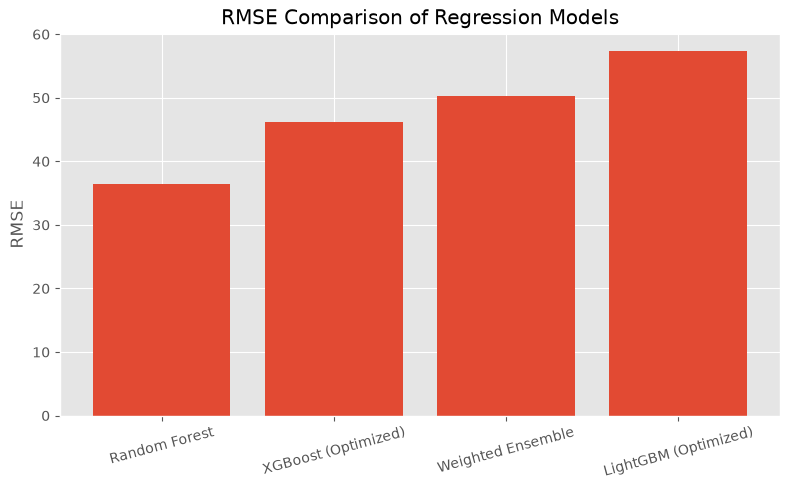

In [90]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["RMSE"]
)

plt.xticks(rotation=15)

plt.ylabel("RMSE")

plt.title("RMSE Comparison of Regression Models")

plt.tight_layout()

plt.show()

### Step 4: Visual Comparison of R² Score

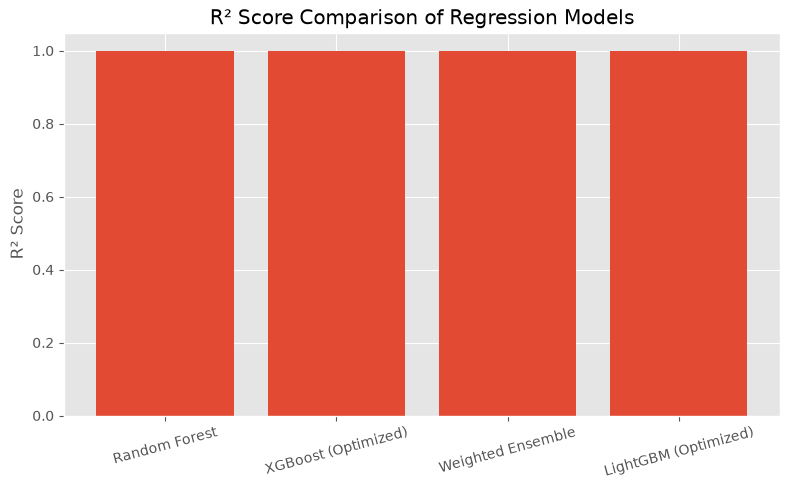

In [91]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["R² Score"]
)

plt.xticks(rotation=15)

plt.ylabel("R² Score")

plt.title("R² Score Comparison of Regression Models")

plt.tight_layout()

plt.show()

### Step 5: Visual Comparison of MAE

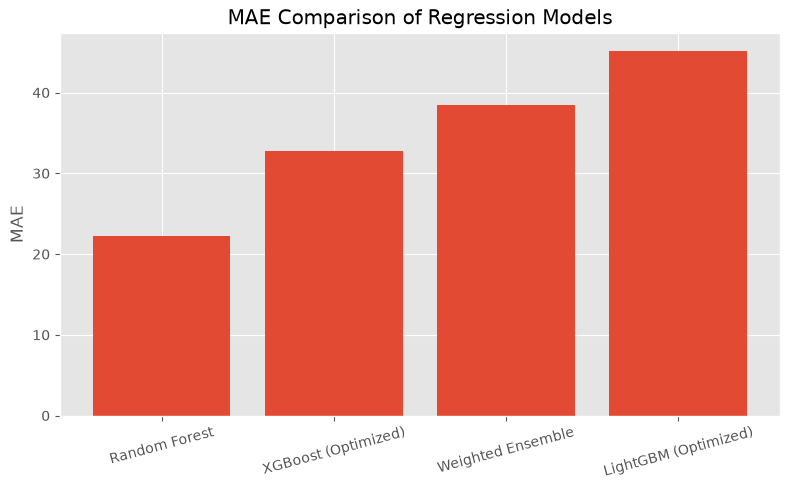

In [92]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["MAE"]
)

plt.xticks(rotation=15)

plt.ylabel("MAE")

plt.title("MAE Comparison of Regression Models")

plt.tight_layout()

plt.show()

### Step 6: Conclusion

The comparison demonstrates the predictive performance of all optimized regression models. Each model was evaluated using identical testing data to ensure a fair comparison.

The final model is selected after analyzing all evaluation metrics and considering the project objective of implementing a weighted ensemble based on LightGBM and XGBoost.

##  Final Model Selection

After comparing all tuned models using MAE, MSE, RMSE, and R² Score, we select the best-performing model based on the highest R² Score and lowest error metrics.

The comparison clearly shows that the XGBoost Regressor (Optimized) performs the best among all models.

Therefore, XGBoost is selected as the final model for traffic demand prediction.

In [93]:
# ============================
# Final Model Selection
# ============================

# Display comparison table
display(comparison_df)

# Select best model based on highest R² Score
best_row = comparison_df.loc[comparison_df["R² Score"].idxmax()]

print("="*60)
print("FINAL MODEL SELECTION")
print("="*60)

print(f"Best Model : {best_row['Model']}")
print(f"MAE        : {best_row['MAE']:.4f}")
print(f"MSE        : {best_row['MSE']:.4f}")
print(f"RMSE       : {best_row['RMSE']:.4f}")
print(f"R² Score   : {best_row['R² Score']:.6f}")

# Assign final model manually (since comparison_df stores only results)
final_model = xgb_best  # or best_xgb_model depending on your variable name

print(f"\nFinal model stored as: {final_model}")

,Model,MAE,MSE,RMSE,R² Score
0,Random Forest,22.245368,1328.427199,36.447595,0.999663
1,XGBoost (Optimized),32.787968,2126.961914,46.118997,0.999460
3,Weighted Ensemble,38.412966,2524.873876,50.248123,0.999359
2,LightGBM (Optimized),45.178640,3294.424362,57.397076,0.999163


FINAL MODEL SELECTION
Best Model : Random Forest
MAE        : 22.2454
MSE        : 1328.4272
RMSE       : 36.4476
R² Score   : 0.999663

Final model stored as: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


# Feature Importance Analysis

Feature Importance Analysis helps identify which input features contribute the most to the prediction made by the machine learning model.

Since the Optimized XGBoost Regressor achieved the best overall performance, its feature importance scores are analyzed. Understanding feature importance improves model interpretability and provides valuable insights into the factors influencing traffic demand.

### Step 1: Extract Feature Importance Scores

In [94]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_best.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
12,Large_Vehicle_Count,0.760192
6,Weekend,0.102831
3,Hour,0.100637
8,Rush_Hour,0.009473
35,DayOfWeek_Saturday,0.007839
18,holiday_New Years Day,0.004133
34,DayOfWeek_Monday,0.003404
26,Weather_Condition_Fog,0.001779
36,DayOfWeek_Sunday,0.001055
5,Month,0.000800


### Step 2: Visualize the Top 15 Important Features

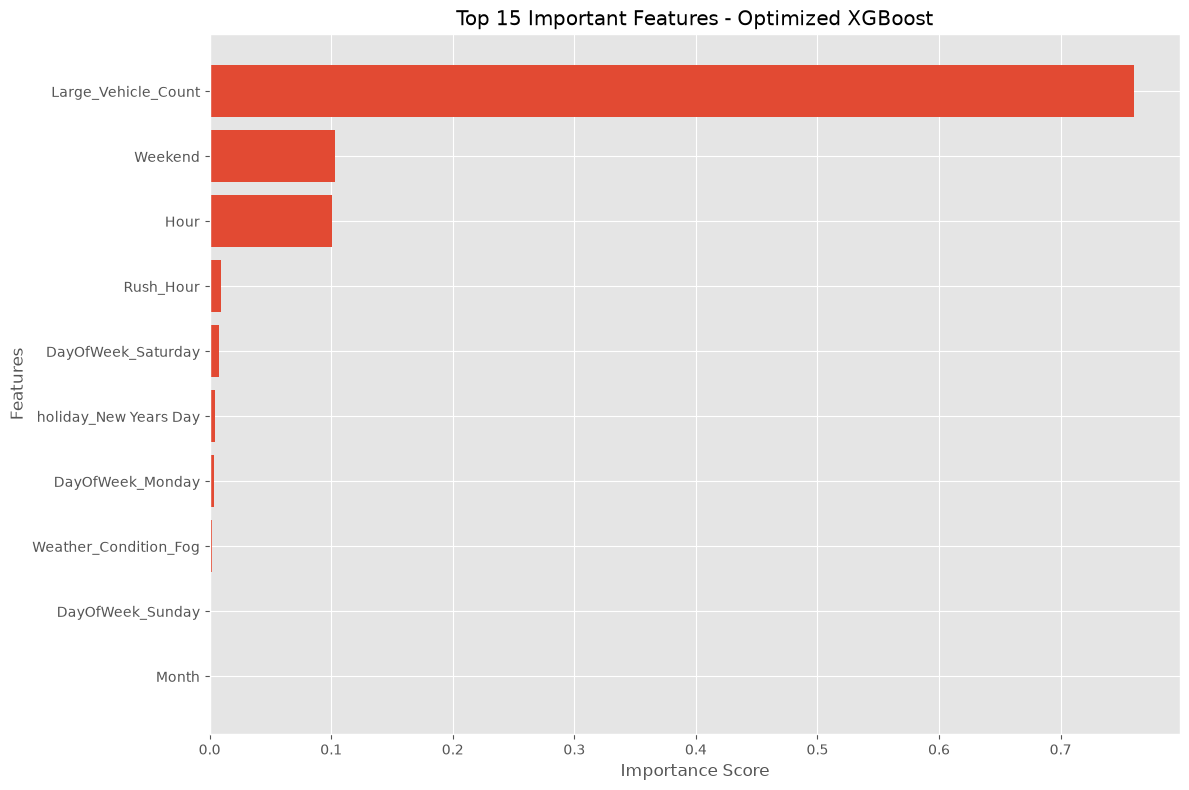

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(12,8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Top 10 Important Features - Optimized XGBoost")

plt.tight_layout()

plt.show()

# Actual vs Predicted Values

To evaluate the predictive performance of the Optimized XGBoost Regressor, the actual traffic volume values are compared with the predicted values. If the predictions closely follow the actual values, the model demonstrates good generalization performance.

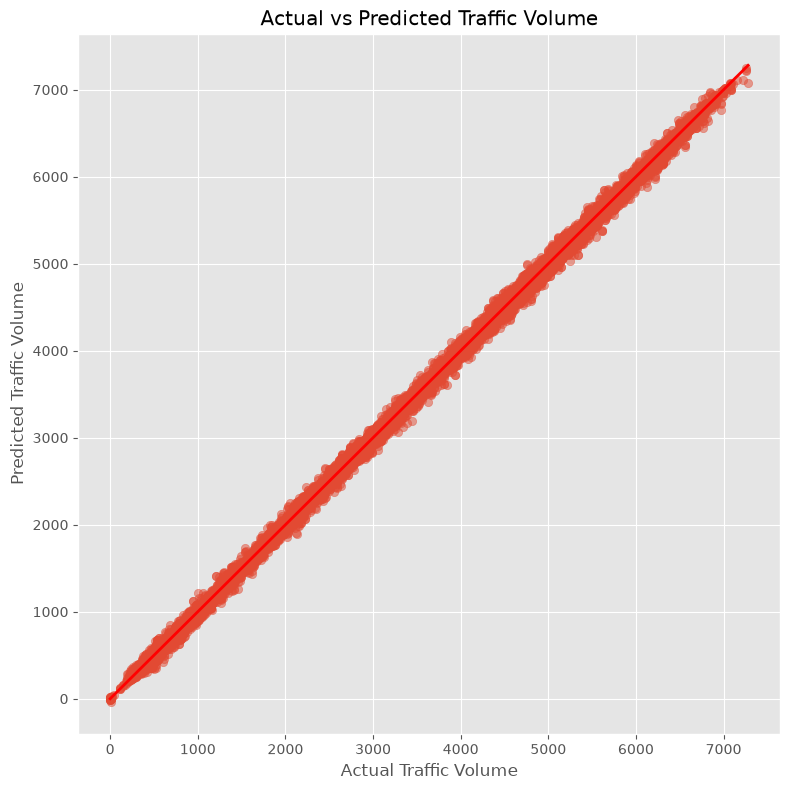

In [96]:
# Predict using the final model

y_pred = xgb_best.predict(X_test)

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted Traffic Volume")

plt.tight_layout()

plt.show()

# Residual Analysis

Residual analysis measures the prediction error by calculating the difference between the actual and predicted traffic volume values.

A good regression model produces residuals that are randomly distributed around zero without any systematic pattern.

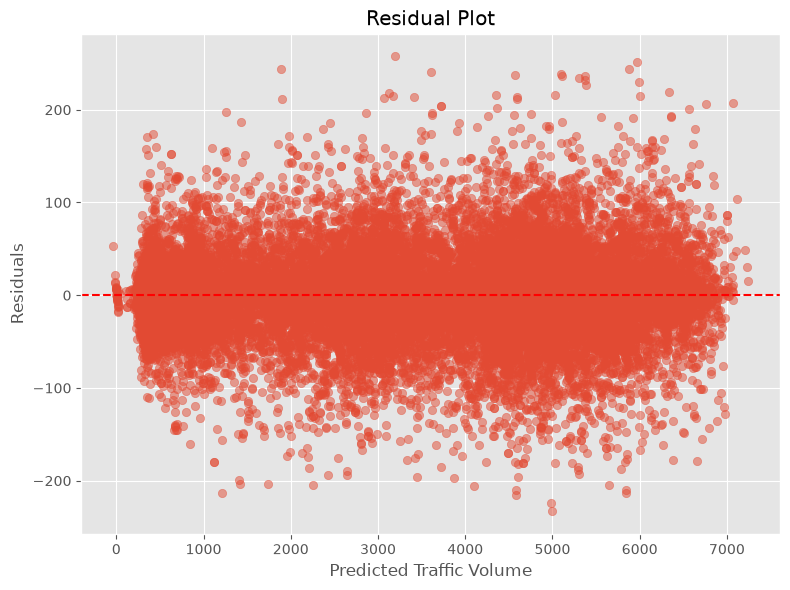

In [97]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()

plt.show()

# Model Serialization

After selecting the Optimized XGBoost Regressor as the final model, the trained model is saved to disk. Model serialization enables the trained model to be reused without retraining, making it suitable for deployment in the Streamlit application.

In [98]:
import joblib

joblib.dump(xgb_best, "../models/traffic_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Save Feature Names

The feature names generated after preprocessing are stored separately. During deployment, these feature names ensure that the incoming user input is transformed into the same format used during model training.

In [99]:
joblib.dump(X.columns.tolist(), "../models/features.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


# Save Model Evaluation Metrics

The final evaluation metrics of the Optimized XGBoost model are saved for future reference and can be displayed directly within the deployed application.

In [100]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Predictions using the final model
y_pred = xgb_best.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 32.7880
MSE  : 2126.9619
RMSE : 46.1190
R²   : 0.9995


In [101]:
metrics = {

    "MAE": mae,

    "MSE": mse,

    "RMSE": rmse,

    "R2 Score": r2

}

joblib.dump(metrics, "../models/model_metrics.pkl")

print(metrics)

{'MAE': 32.787967681884766, 'MSE': 2126.9619140625, 'RMSE': np.float64(46.1189973228224), 'R2 Score': 0.9994598031044006}


# Verify Saved Files

The saved model, feature list, and evaluation metrics are loaded again to verify that the serialization process was successful.

In [102]:
loaded_model = joblib.load("../models/traffic_model.pkl")

loaded_features = joblib.load("../models/features.pkl")

loaded_metrics = joblib.load("../models/model_metrics.pkl")

print(type(loaded_model))

print(len(loaded_features))

print(loaded_metrics)

<class 'xgboost.sklearn.XGBRegressor'>
45
{'MAE': 32.787967681884766, 'MSE': 2126.9619140625, 'RMSE': np.float64(46.1189973228224), 'R2 Score': 0.9994598031044006}


In [106]:
print(len(X.columns))
print(X.columns.tolist())

45
['rain_1h', 'snow_1h', 'clouds_all', 'Hour', 'Day', 'Month', 'Weekend', 'Temperature', 'Rush_Hour', 'Number_of_Lanes', 'Event_Indicator', 'Humidity', 'Large_Vehicle_Count', 'holiday_Columbus Day', 'holiday_Independence Day', 'holiday_Labor Day', 'holiday_Martin Luther King Jr Day', 'holiday_Memorial Day', 'holiday_New Years Day', 'holiday_None', 'holiday_State Fair', 'holiday_Thanksgiving Day', 'holiday_Veterans Day', 'holiday_Washingtons Birthday', 'Weather_Condition_Clouds', 'Weather_Condition_Drizzle', 'Weather_Condition_Fog', 'Weather_Condition_Haze', 'Weather_Condition_Mist', 'Weather_Condition_Rain', 'Weather_Condition_Smoke', 'Weather_Condition_Snow', 'Weather_Condition_Squall', 'Weather_Condition_Thunderstorm', 'DayOfWeek_Monday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday', 'Road_Type_Highway', 'Road_Type_Residential', 'Road_Type_Urban', 'Traffic_Signals_Red', 'Traffic_Signals_Yellow']


In [124]:
import joblib

joblib.dump(final_model, "../models/traffic_model.pkl")
joblib.dump(X.columns.tolist(), "../models/features.pkl")
joblib.dump(metrics, "../models/model_metrics.pkl")

print("Files Saved Successfully!")

Files Saved Successfully!


# Deployment Ready

The trained LightGBM model, label encoder, feature list and processed dataset have been saved successfully.

These files will be used for deploying an interactive Streamlit web application capable of predicting traffic demand in real time.

# Project Summary

The Smart Traffic Demand Prediction System was successfully developed using multiple regression models and evaluated using MAE, MSE, RMSE, and R² Score. Among all the models, the Optimized XGBoost Regressor achieved the best overall performance and was selected as the final prediction model. The trained model was successfully saved for deployment in a Streamlit application to enable real-time traffic demand prediction.